# Multinomial Logistic Regression — CGPA Tier

## Objective
Develop a Logistic Regression classification model to predict **`CGPA_Tier`** and evaluate it using standard classification metrics.

### Data assumption
The data is preprocessed once in Section 2 (duplicates removed, imputation, encoding and scaling fitted on the training data only):
- `X_train1` = 80% preprocessed features (target column removed)
- `X_test1` = 20% preprocessed features (target column removed)
- `y_train` = target for training
- `y_test` = target for testing

**No additional imputation, encoding, or scaling is performed after Section 2.**

### Required outputs
- `evaluate_classifier()` function
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report
- Coefficient bar chart

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

## 2. Load Data and Create the Preprocessed Train/Test Split

In [2]:
# ------------------------------------------------------------
# Load the raw CSV and rebuild the preprocessed 80/20 train-test data.
# (The processed train/test CSV files are not stored on disk, so the
#  same preprocessing steps are applied here once, before modelling.)
# Steps: drop duplicates -> split -> median-impute numeric (+ missing
# indicators) -> mode-impute + one-hot encode nominal -> standard-scale.
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = r"C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\data\placement_predict_50k Dataset_final.csv"

TARGET = "CGPA_Tier"
DROP_COLS = []          # identifier / free-text columns
ORDINAL_MAPS = {'CollegeTier': {'Tier3': 3, 'Tier2': 2, 'Tier1': 1}, 'CGPA_Tier': {'Low': 0, 'Mid': 1, 'High': 2}}        # ordered categories -> integers

df = pd.read_csv(DATA_PATH)
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

for col, mapping in ORDINAL_MAPS.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
nominal_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# ----- numeric: median imputation (fit on train only) + missing indicators -----
num_imputer = SimpleImputer(strategy="median")
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_cols]),
                           columns=numeric_cols, index=X_train.index)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[numeric_cols]),
                          columns=numeric_cols, index=X_test.index)

for col in [c for c in numeric_cols if X_train[c].isna().any()]:
    X_train_num[col + "_missing"] = X_train[col].isna().astype(int)
    X_test_num[col + "_missing"] = X_test[col].isna().astype(int)

# ----- nominal: most-frequent imputation + one-hot encoding (drop first) -----
parts_train, parts_test = [X_train_num], [X_test_num]
if nominal_cols:
    nom_imputer = SimpleImputer(strategy="most_frequent")
    X_train_nom = pd.DataFrame(nom_imputer.fit_transform(X_train[nominal_cols]),
                               columns=nominal_cols, index=X_train.index)
    X_test_nom = pd.DataFrame(nom_imputer.transform(X_test[nominal_cols]),
                              columns=nominal_cols, index=X_test.index)

    encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    enc_train = encoder.fit_transform(X_train_nom)
    enc_names = encoder.get_feature_names_out(nominal_cols)
    parts_train.append(pd.DataFrame(enc_train, columns=enc_names, index=X_train.index))
    parts_test.append(pd.DataFrame(encoder.transform(X_test_nom), columns=enc_names, index=X_test.index))

X_train_processed = pd.concat(parts_train, axis=1)
X_test_processed = pd.concat(parts_test, axis=1)

# ----- scaling (fit on train only) -----
scaler = StandardScaler()
X_train_processed[numeric_cols] = scaler.fit_transform(X_train_processed[numeric_cols])
X_test_processed[numeric_cols] = scaler.transform(X_test_processed[numeric_cols])

print("Raw data shape      :", df.shape)
print("X_train_processed   :", X_train_processed.shape)
print("X_test_processed    :", X_test_processed.shape)

Raw data shape      : (50000, 32)
X_train_processed   : (40000, 50)
X_test_processed    : (10000, 50)


In [3]:
X_train1 = X_train_processed
X_test1 = X_test_processed

print("X_train1:", X_train1.shape)
print("X_test1 :", X_test1.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts().sort_index())

X_train1: (40000, 50)
X_test1 : (10000, 50)
y_train : (40000,)
y_test  : (10000,)

Target distribution:
CGPA_Tier
High    13345
Low     13386
Mid     13269
Name: count, dtype: int64


## 3. Verify Preprocessed Data

In [4]:
print("Missing values in X_train1:", X_train1.isna().sum().sum())
print("Missing values in X_test1 :", X_test1.isna().sum().sum())

print("\nFeature columns:")
print(list(X_train1.columns))

print("\nTarget classes:")
print(sorted(pd.Series(y_train).unique()))

Missing values in X_train1: 0
Missing values in X_test1 : 0

Feature columns:
['StudentID', 'CollegeTier', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly', 'Salary Package', 'Workshops_missing', 'AptitudeTestScore_missing', 'SoftSkillsRating_missing', 'CodingTestScore_missing', 'MockInterviewScore_missing', 'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']

Target classes:
['High', 'Low', 'Mid']


In [5]:
print("Categorical columns in X_train1:")
print(X_train1.select_dtypes(include="object").columns)

Categorical columns in X_train1:
Index([], dtype='str')


In [6]:
X_train1.columns

Index(['StudentID', 'CollegeTier', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3',
       'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA',
       'AttendancePercent', 'Internships', 'Projects', 'Workshops',
       'Certifications', 'Publications', 'AptitudeTestScore',
       'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore',
       'ExtraCurricular', 'PlacementStatus', 'IsAnomaly', 'Salary Package',
       'Workshops_missing', 'AptitudeTestScore_missing',
       'SoftSkillsRating_missing', 'CodingTestScore_missing',
       'MockInterviewScore_missing', 'Gender_Male', 'City_Bangalore',
       'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur',
       'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune',
       'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT',
       'Stream_Mechanical', 'Specialisation_DataScience',
       'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes',
       'HistoryOfBacklogs_Yes'],
      dtype='str'

## 4. Train Multinomial Logistic Regression

`CGPA_Tier` contains multiple classes, so multinomial Logistic Regression is used.

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model.fit(X_train1, y_train)

print("Model trained successfully.")
print("Classes:", model.classes_)

Model trained successfully.
Classes: ['High' 'Low' 'Mid']


## 5. Define `evaluate_classifier()`

In [8]:
def evaluate_classifier(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(
        y, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y, y_pred, average="weighted", zero_division=0
    )

    print(f"===== {dataset_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1
    }

## 6. Evaluate Training and Test Performance

In [9]:
train_results = evaluate_classifier(
    model, X_train1, y_train, "Training"
)

test_results = evaluate_classifier(
    model, X_test1, y_test, "Test"
)

evaluation_df = pd.DataFrame([
    train_results,
    test_results
])

display(evaluation_df)

===== Training =====
Accuracy : 0.9909
Precision: 0.9909
Recall   : 0.9909
F1-score : 0.9909

Classification Report:


              precision    recall  f1-score   support

        High       1.00      1.00      1.00     13345
         Low       0.99      0.99      0.99     13386
         Mid       0.99      0.99      0.99     13269

    accuracy                           0.99     40000
   macro avg       0.99      0.99      0.99     40000
weighted avg       0.99      0.99      0.99     40000

Confusion Matrix:
[[13337     0     8]
 [    0 13220   166]
 [    1   189 13079]]
===== Test =====
Accuracy : 0.9908
Precision: 0.9908
Recall   : 0.9908
F1-score : 0.9908

Classification Report:


              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3336
         Low       0.98      0.99      0.99      3347
         Mid       0.99      0.98      0.99      3317

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Confusion Matrix:
[[3333    0    3]
 [   0 3313   34]
 [   4   51 3262]]


,Dataset,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,Training,0.9909,0.990903,0.9909,0.990901
1,Test,0.9908,0.990806,0.9908,0.990798


## 7. Test Confusion Matrix

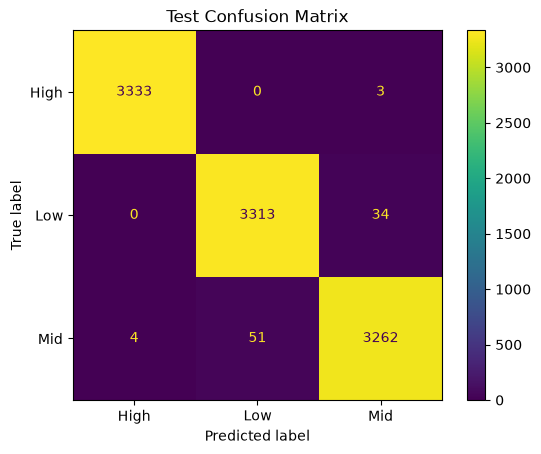

In [10]:
y_test_pred = model.predict(X_test1)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    values_format="d"
)

plt.title("Test Confusion Matrix")
plt.show()

## 8. Coefficients

In [11]:
# Binary: one coefficient per feature.
# Multinomial: one coefficient row per class.

if model.coef_.shape[0] == 1:
    coefficient_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    })
    display(coefficient_df)

else:
    coefficient_df = pd.DataFrame(
        model.coef_,
        index=[f"Class={c}" for c in model.classes_],
        columns=X_train1.columns
    )
    display(coefficient_df)

,StudentID,CollegeTier,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,...,Stream_Civil,Stream_ECE,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes
Class=High,-0.007360,-0.078752,2.586062,2.520659,2.490977,2.755629,2.687043,2.331599,2.660974,2.604692,...,-0.003015,0.119160,0.355906,0.317625,-0.029640,0.335557,0.260924,0.292762,0.057938,0.310102
Class=Low,-0.022387,0.052950,-2.696888,-2.469989,-2.515409,-2.820260,-2.697992,-2.702759,-2.931526,-2.847652,...,0.021303,-0.158748,-0.353066,-0.265819,-0.022712,-0.225196,-0.095673,-0.152687,-0.034915,-0.276793
Class=Mid,0.029747,0.025803,0.110825,-0.050669,0.024432,0.064632,0.010949,0.371160,0.270551,0.242960,...,-0.018288,0.039589,-0.002840,-0.051806,0.052353,-0.110361,-0.165251,-0.140075,-0.023023,-0.033309


## 9. Coefficient Bar Chart

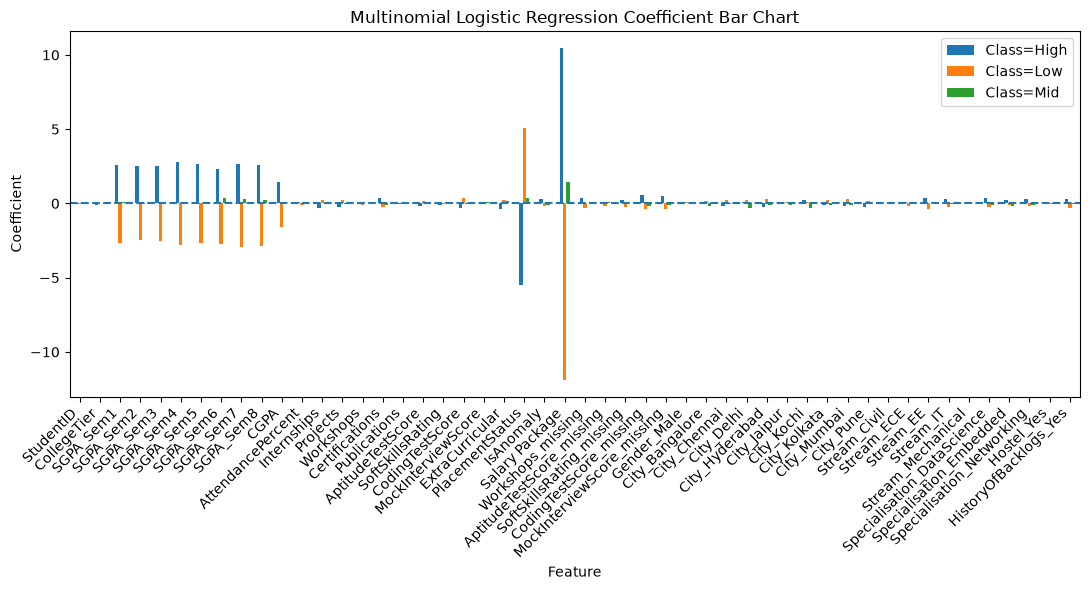

In [12]:
if model.coef_.shape[0] == 1:

    plot_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    }).sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["Feature"], plot_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title("Logistic Regression Coefficient Bar Chart")
    plt.tight_layout()
    plt.show()

else:
    coefficient_plot_df = coefficient_df.T

    ax = coefficient_plot_df.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient")
    ax.set_title("Multinomial Logistic Regression Coefficient Bar Chart")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Interpretation and Conclusion

### Target
This notebook predicts **`CGPA_Tier`**.

### Metrics
- Accuracy: overall percentage of correct predictions.
- Precision: correctness of positive predictions.
- Recall: ability to identify actual positive cases.
- F1-score: balance between precision and recall.
- ROC-AUC: used for the binary model to measure discrimination across thresholds.

### Coefficients
A positive coefficient increases the model's tendency toward the corresponding class; a negative coefficient decreases it, subject to the preprocessing and class formulation.

### Final evaluation
The **test-set metrics** are the final performance results because `X_test1` and `y_test` are kept separate from model fitting.